# Phase 1 -- Exploratory Data Analysis and Baseline Models
## Human vs. AI-Generated Text Classification

**Objectives:**
1. Understand class distribution and severe imbalance (19:1)
2. Analyse text length, vocabulary richness, misspelling patterns, and n-grams
3. Train TF-IDF baselines (Logistic Regression, LinearSVC)
4. Establish a validated Macro F1 benchmark for later phases


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

LABEL_MAP = {
    0: 'Human',
    1: 'DeepSeek',
    2: 'Grok',
    3: 'Claude',
    4: 'Gemini',
    5: 'ChatGPT'
    }

COLORS = {
    'Human': '#2ecc71',
    'DeepSeek': '#e74c3c',
    'Grok': '#9b59b6',
    'Claude': '#f39c12',
    'Gemini': '#3498db',
    'ChatGPT': '#1abc9c'
    }

print('Libraries loaded ')

Libraries loaded 


## 1. Load & Inspect Data

In [35]:
import os
os.chdir('/Users/aliivaezii/Documents/MALTO')

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')
print(f'\nTrain columns: {list(train.columns)}')
print(f'Test columns: {list(test.columns)}')
print(f'\nTrain nulls:\n{train.isnull().sum()}')
print(f'\nTest nulls:\n{test.isnull().sum()}')
print(f'\nTrain dtypes:\n{train.dtypes}')

# Add readable label names
train['label_name'] = train['LABEL'].map(LABEL_MAP)

train.head(3)

Train shape: (2400, 2)
Test shape: (600, 2)

Train columns: ['TEXT', 'LABEL']
Test columns: ['Unnamed: 0', 'TEXT']

Train nulls:
TEXT     0
LABEL    0
dtype: int64

Test nulls:
Unnamed: 0    0
TEXT          0
dtype: int64

Train dtypes:
TEXT     object
LABEL     int64
dtype: object


,TEXT,LABEL,label_name
0,"Dear state senator, There should be a change i...",0,Human
1,A star's life cycle begins in a nebula and pro...,1,DeepSeek
2,Limiting the usage of has a variety advantages...,0,Human


## 2. Class Distribution

=== Class Distribution ===
 Label 0 (   Human):  1520 samples ( 63.3%) 
 Label 1 (DeepSeek):    80 samples (  3.3%) 
 Label 2 (    Grok):   160 samples (  6.7%) 
 Label 3 (  Claude):    80 samples (  3.3%) 
 Label 4 (  Gemini):   240 samples ( 10.0%) 
 Label 5 ( ChatGPT):   320 samples ( 13.3%) 

 Total: 2400 samples

 Imbalance ratio (max/min): 19.0x


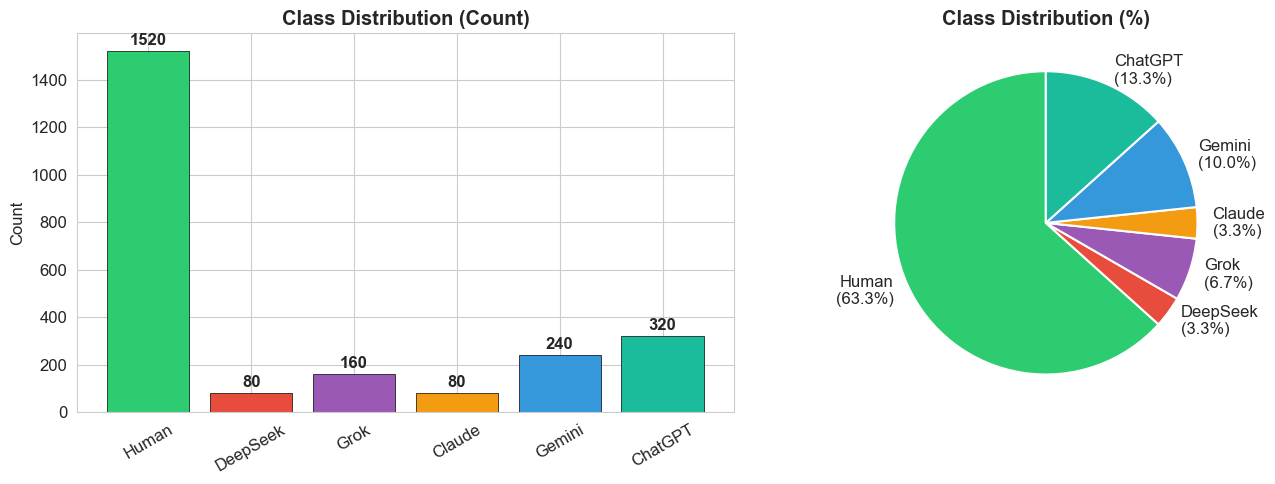

In [36]:
class_counts = train['LABEL'].value_counts().sort_index()
class_pcts = (class_counts / len(train) * 100).round(1)

print('=== Class Distribution ===')
for label, count in class_counts.items():
    name = LABEL_MAP[label]
    pct = class_pcts[label]
    bar = '' * int(pct)
    print(f' Label {label} ({name:>8s}): {count:>5d} samples ({pct:>5.1f}%) {bar}')
print(f'\n Total: {len(train)} samples')
print(f'\n Imbalance ratio (max/min): {class_counts.max() / class_counts.min():.1f}x')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(
    [LABEL_MAP[i] for i in class_counts.index],
    class_counts.values,
    color=[COLORS[LABEL_MAP[i]] for i in class_counts.index],
    edgecolor='black', linewidth=0.5
    )
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 15,
        f'{count}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Class Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=[f"{LABEL_MAP[i]}\n({class_pcts[i]}%)" for i in class_counts.index],
    colors=[COLORS[LABEL_MAP[i]] for i in class_counts.index],
    startangle=90, autopct='', wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
axes[1].set_title('Class Distribution (%)', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Text Length Analysis

=== Text Length Statistics by Class ===


char_count                 word_count               sentence_count  \
                 mean  median     std       mean median    std           mean   
label_name                                                                      
ChatGPT        1485.2  1321.5   468.4      179.4  153.0   74.3            9.9   
Claude         3358.7  3256.0   925.0      375.6  359.5  115.1           72.8   
DeepSeek        560.0   172.0   568.6       83.1   23.5   86.0            3.5   
Gemini         2818.7  2855.5  1519.0      419.9  424.5  224.5           19.9   
Grok            414.5   232.0   328.5       55.6   33.0   44.6            2.4   
Human          2510.6  2537.5  1489.2      450.9  452.5  271.9           28.2   

                        avg_word_len              
           median   std         mean median  std  
label_name                                        
ChatGPT       9.0   3.8          7.5    7.7  0.6  
Claude       76.5  10.9          8.0    8.1  0.4  
DeepSeek      1.0   3.5          6.0    5.9  0.7  
Gemini       21.0  11.6          5.7    5.7  0.2  
Grok          1.0   2.1          6.5    6.4  0.7  
Human        24.0  21.5          4.6    4.6  0.3

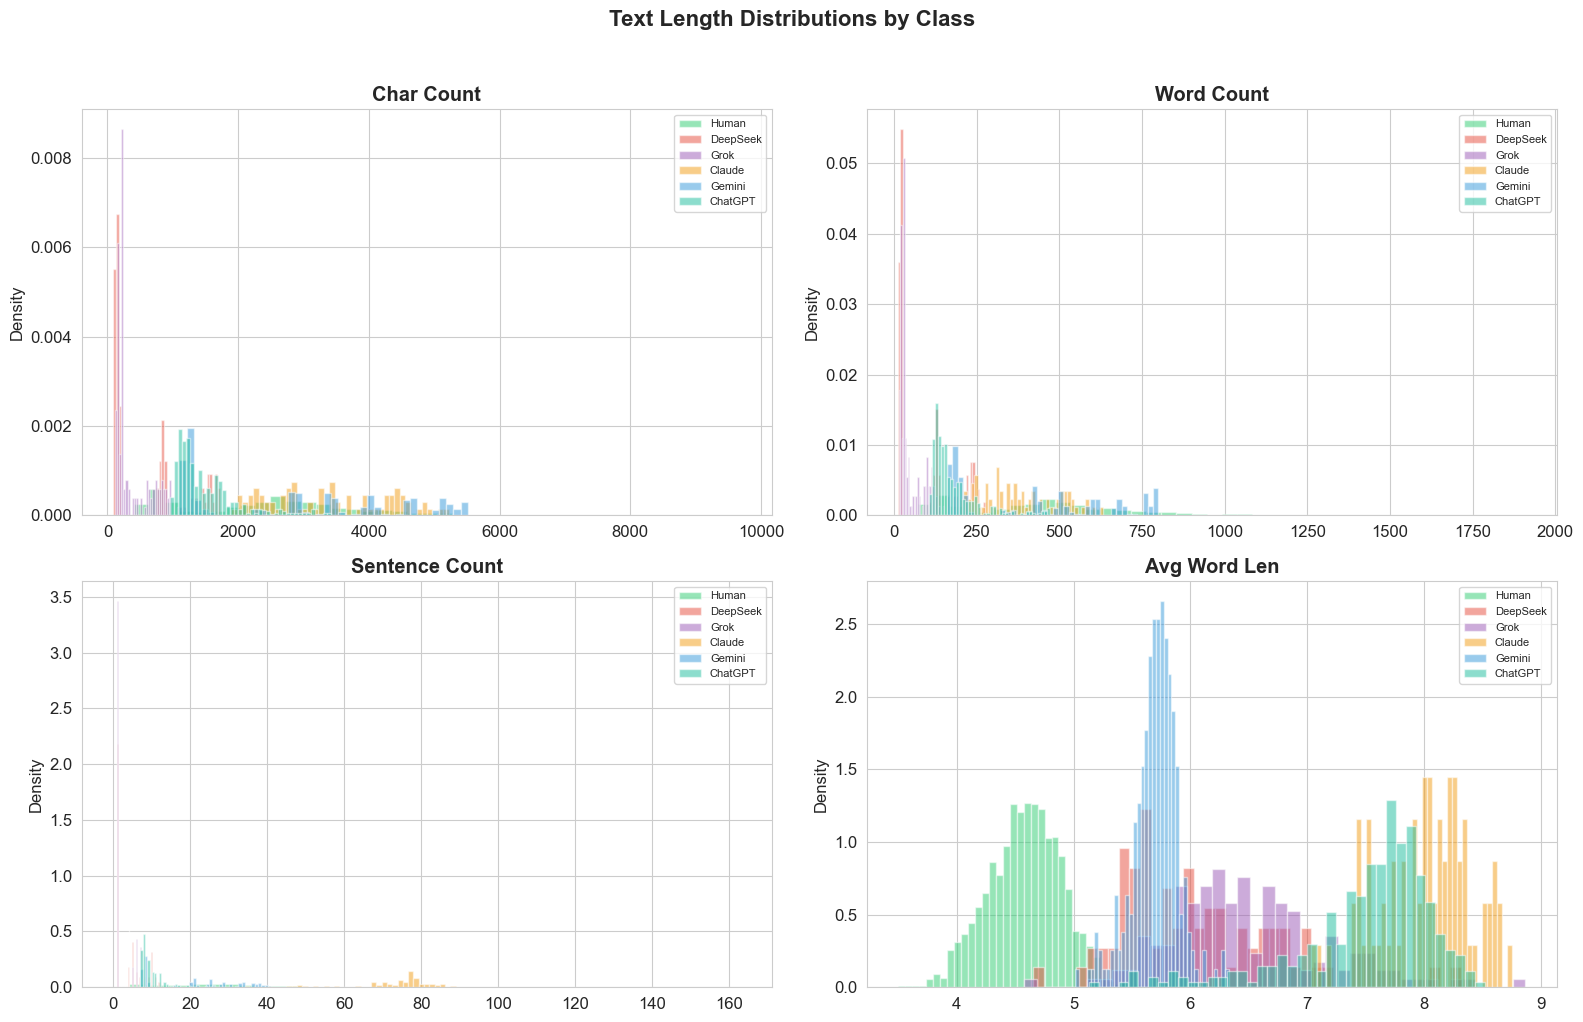

In [37]:
# Compute text statistics
train['char_count'] = train['TEXT'].str.len()
train['word_count'] = train['TEXT'].str.split().str.len()
train['sentence_count'] = train['TEXT'].str.count(r'[.!?]+')
train['avg_word_len'] = train['TEXT'].apply(lambda x: np.mean([len(w) for w in x.split()]))

stats_cols = ['char_count', 'word_count', 'sentence_count', 'avg_word_len']

print('=== Text Length Statistics by Class ===')
summary = train.groupby('label_name')[stats_cols].agg(['mean', 'median', 'std']).round(1)
display(summary)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, col in enumerate(stats_cols):
    ax = axes[idx // 2][idx % 2]
    for label in sorted(train['LABEL'].unique()):
        name = LABEL_MAP[label]
        subset = train[train['LABEL'] == label][col]
        ax.hist(subset, bins=40, alpha=0.5, label=name, color=COLORS[name], density=True)
        ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
        ax.legend(fontsize=8)
        ax.set_ylabel('Density')

plt.suptitle('Text Length Distributions by Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/text_length_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

###  Distribution Plots by Class

Visualise how character count, word count, sentence count, and average word length vary across the six source classes.

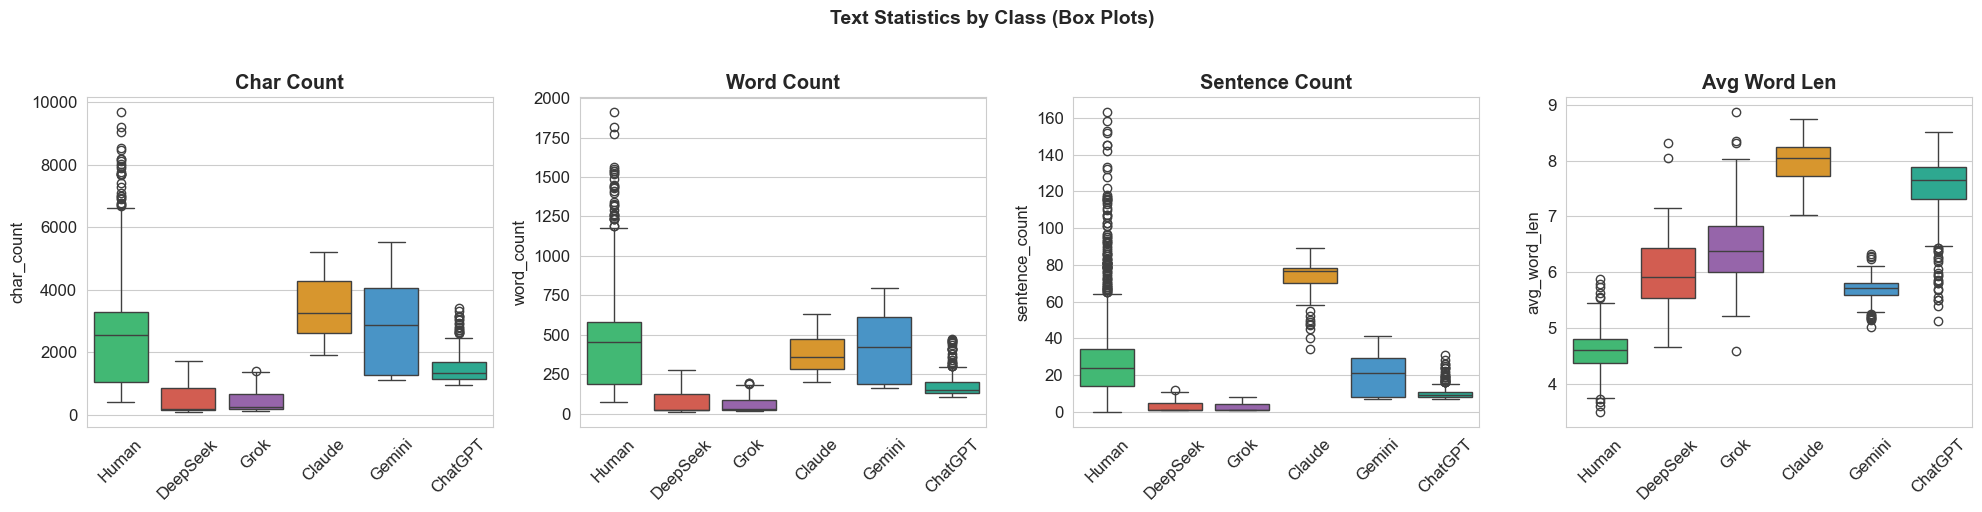

In [38]:
# Box plots for clearer comparison
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, col in enumerate(stats_cols):
    order = ['Human', 'DeepSeek', 'Grok', 'Claude', 'Gemini', 'ChatGPT']
    palette = [COLORS[name] for name in order]
    sns.boxplot(data=train, x='label_name', y=col, ax=axes[idx],
        order=order, palette=palette)
    axes[idx].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Text Statistics by Class (Box Plots)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Spelling & Typo Analysis
**Key hypothesis:** Human-written text contains spelling errors, while AI-generated text is typically clean.

Computing misspelling features (this may take a moment)...

=== Misspelling Ratio by Class ===

=== Misspelling Ratio by Class ===


,mean,median,std
label_name,,,
Claude,0.2857,0.2886,0.0398
Grok,0.2442,0.2329,0.0695
ChatGPT,0.2280,0.2279,0.0401
DeepSeek,0.1896,0.1752,0.0724
Gemini,0.1527,0.1519,0.0209
Human,0.1415,0.1397,0.0393


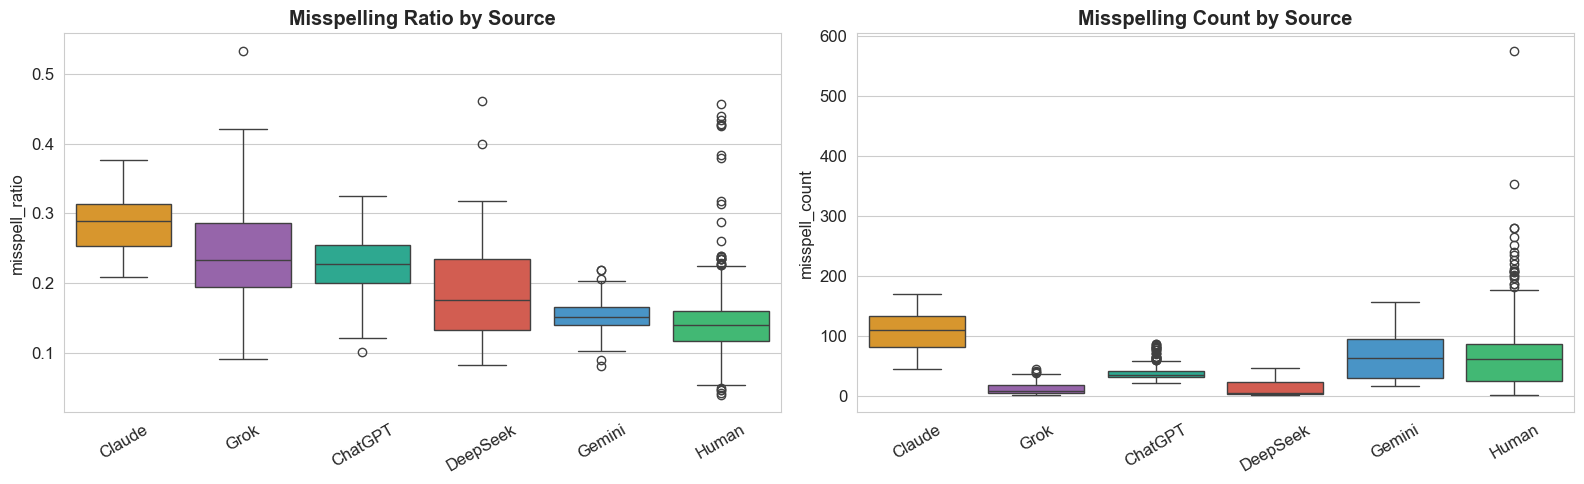

In [39]:
import nltk
nltk.download('words', quiet=True)
from nltk.corpus import words

# Build a set of known English words
english_words = set(w.lower() for w in words.words())

def count_misspellings(text):
    """Count words not in the English dictionary (proxy for misspellings)."""
    tokens = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    if len(tokens) == 0:
        return 0, 0.0
    misspelled = sum(1 for t in tokens if t not in english_words and len(t) > 2)
    ratio = misspelled / len(tokens)
    return misspelled, ratio

print('Computing misspelling features (this may take a moment)...')
spell_results = train['TEXT'].apply(count_misspellings)
train['misspell_count'] = spell_results.apply(lambda x: x[0])
train['misspell_ratio'] = spell_results.apply(lambda x: x[1])

print('\n=== Misspelling Ratio by Class ===')
spell_stats = train.groupby('label_name')['misspell_ratio'].agg(['mean', 'median', 'std']).round(4)
spell_stats = spell_stats.sort_values('mean', ascending=False)
display(spell_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Misspelling ratio by class
order_by_mean = spell_stats.index.tolist()
palette = [COLORS[name] for name in order_by_mean]
sns.boxplot(data=train, x='label_name', y='misspell_ratio', ax=axes[0],
    order=order_by_mean, palette=palette)
axes[0].set_title('Misspelling Ratio by Source', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# Misspelling count by class
sns.boxplot(data=train, x='label_name', y='misspell_count', ax=axes[1],
    order=order_by_mean, palette=palette)
axes[1].set_title('Misspelling Count by Source', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('figures/misspelling_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Vocabulary Richness & Linguistic Features

In [40]:
def compute_linguistic_features(text):
    """Compute a set of linguistic features for a text."""
    words_list = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if s.strip()]
 
    n_words = len(words_list)
    n_unique = len(set(words_list))
    n_sentences = max(len(sentences), 1)
 
    # Type-Token Ratio (vocabulary diversity)
    ttr = n_unique / n_words if n_words > 0 else 0
 
    # Average sentence length (in words)
    avg_sent_len = n_words / n_sentences
 
    # Punctuation density
    punct_count = sum(1 for c in text if c in string.punctuation)
    punct_ratio = punct_count / len(text) if len(text) > 0 else 0
 
    # Uppercase ratio
    upper_count = sum(1 for c in text if c.isupper())
    upper_ratio = upper_count / len(text) if len(text) > 0 else 0
 
    # Digit ratio
    digit_count = sum(1 for c in text if c.isdigit())
    digit_ratio = digit_count / len(text) if len(text) > 0 else 0
 
    # Comma density
    comma_ratio = text.count(',') / n_words if n_words > 0 else 0
 
    # Paragraph count (double newlines)
    para_count = text.count('\n\n') + 1
 
    # Long word ratio (> 8 chars)
    long_words = sum(1 for w in words_list if len(w) > 8)
    long_word_ratio = long_words / n_words if n_words > 0 else 0
 
    return {
        'ttr': ttr,
        'avg_sent_len': avg_sent_len,
        'punct_ratio': punct_ratio,
        'upper_ratio': upper_ratio,
        'digit_ratio': digit_ratio,
        'comma_ratio': comma_ratio,
        'para_count': para_count,
        'long_word_ratio': long_word_ratio,
        }

print('Computing linguistic features...')
ling_features = train['TEXT'].apply(compute_linguistic_features)
ling_df = pd.DataFrame(ling_features.tolist())
for col in ling_df.columns:
    train[col] = ling_df[col]

print('\n=== Linguistic Features by Class (Mean) ===')
ling_cols = ['ttr', 'avg_sent_len', 'punct_ratio', 'upper_ratio', 'comma_ratio', 'long_word_ratio']
display(train.groupby('label_name')[ling_cols].mean().round(4))

Computing linguistic features...

=== Linguistic Features by Class (Mean) ===

=== Linguistic Features by Class (Mean) ===


,ttr,avg_sent_len,punct_ratio,upper_ratio,comma_ratio,long_word_ratio
label_name,,,,,,
ChatGPT,0.7204,18.2005,0.0282,0.0043,0.1688,0.3643
Claude,0.5991,5.5589,0.0288,0.0241,0.0325,0.3591
DeepSeek,0.8630,22.2653,0.0192,0.0120,0.0626,0.1854
Gemini,0.5954,22.3728,0.0172,0.0099,0.0534,0.1920
Grok,0.9076,24.9453,0.0199,0.0135,0.0867,0.2290
Human,0.5294,17.6453,0.0317,0.0547,0.0442,0.0687


###  Feature Heatmap

Heatmap of mean linguistic feature values per class, normalised for comparison.

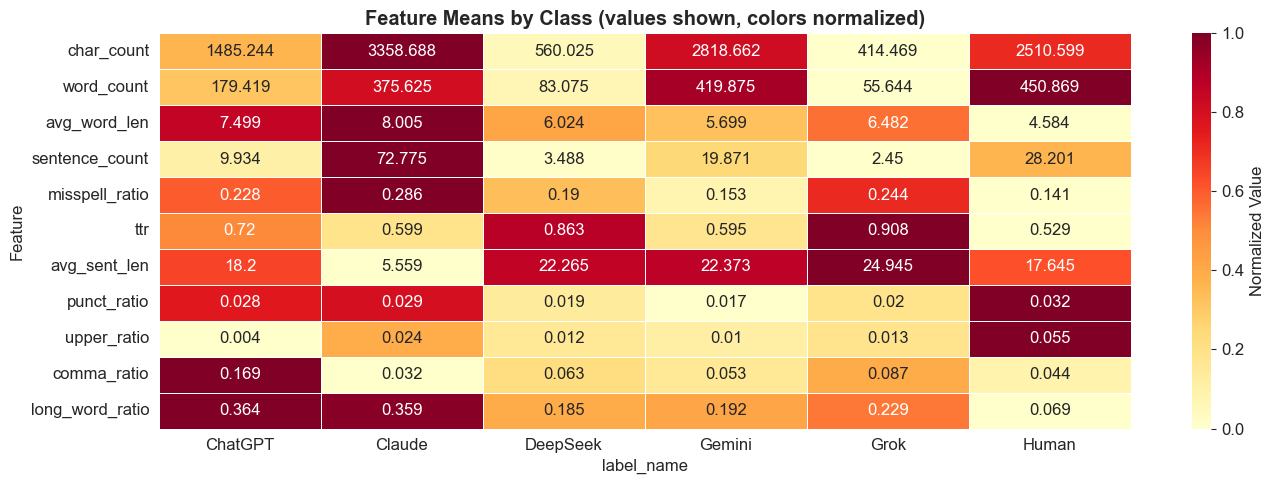

In [41]:
# Heatmap: mean feature values by class (normalized)
feature_cols = ['char_count', 'word_count', 'avg_word_len', 'sentence_count',
    'misspell_ratio', 'ttr', 'avg_sent_len', 'punct_ratio',
    'upper_ratio', 'comma_ratio', 'long_word_ratio']

means = train.groupby('label_name')[feature_cols].mean()
# Normalize each feature to [0,1] for comparison
means_norm = (means - means.min()) / (means.max() - means.min())

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(means_norm.T, annot=means.T.round(3), fmt='', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalized Value'})
ax.set_title('Feature Means by Class (values shown, colors normalized)', fontweight='bold')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('figures/feature_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

###  Linguistic Feature Extraction

Compute deeper linguistic features — readability indices, punctuation patterns, and more — to find additional separability signals.

## 6. N-gram Analysis -- Top Words/Phrases per Class

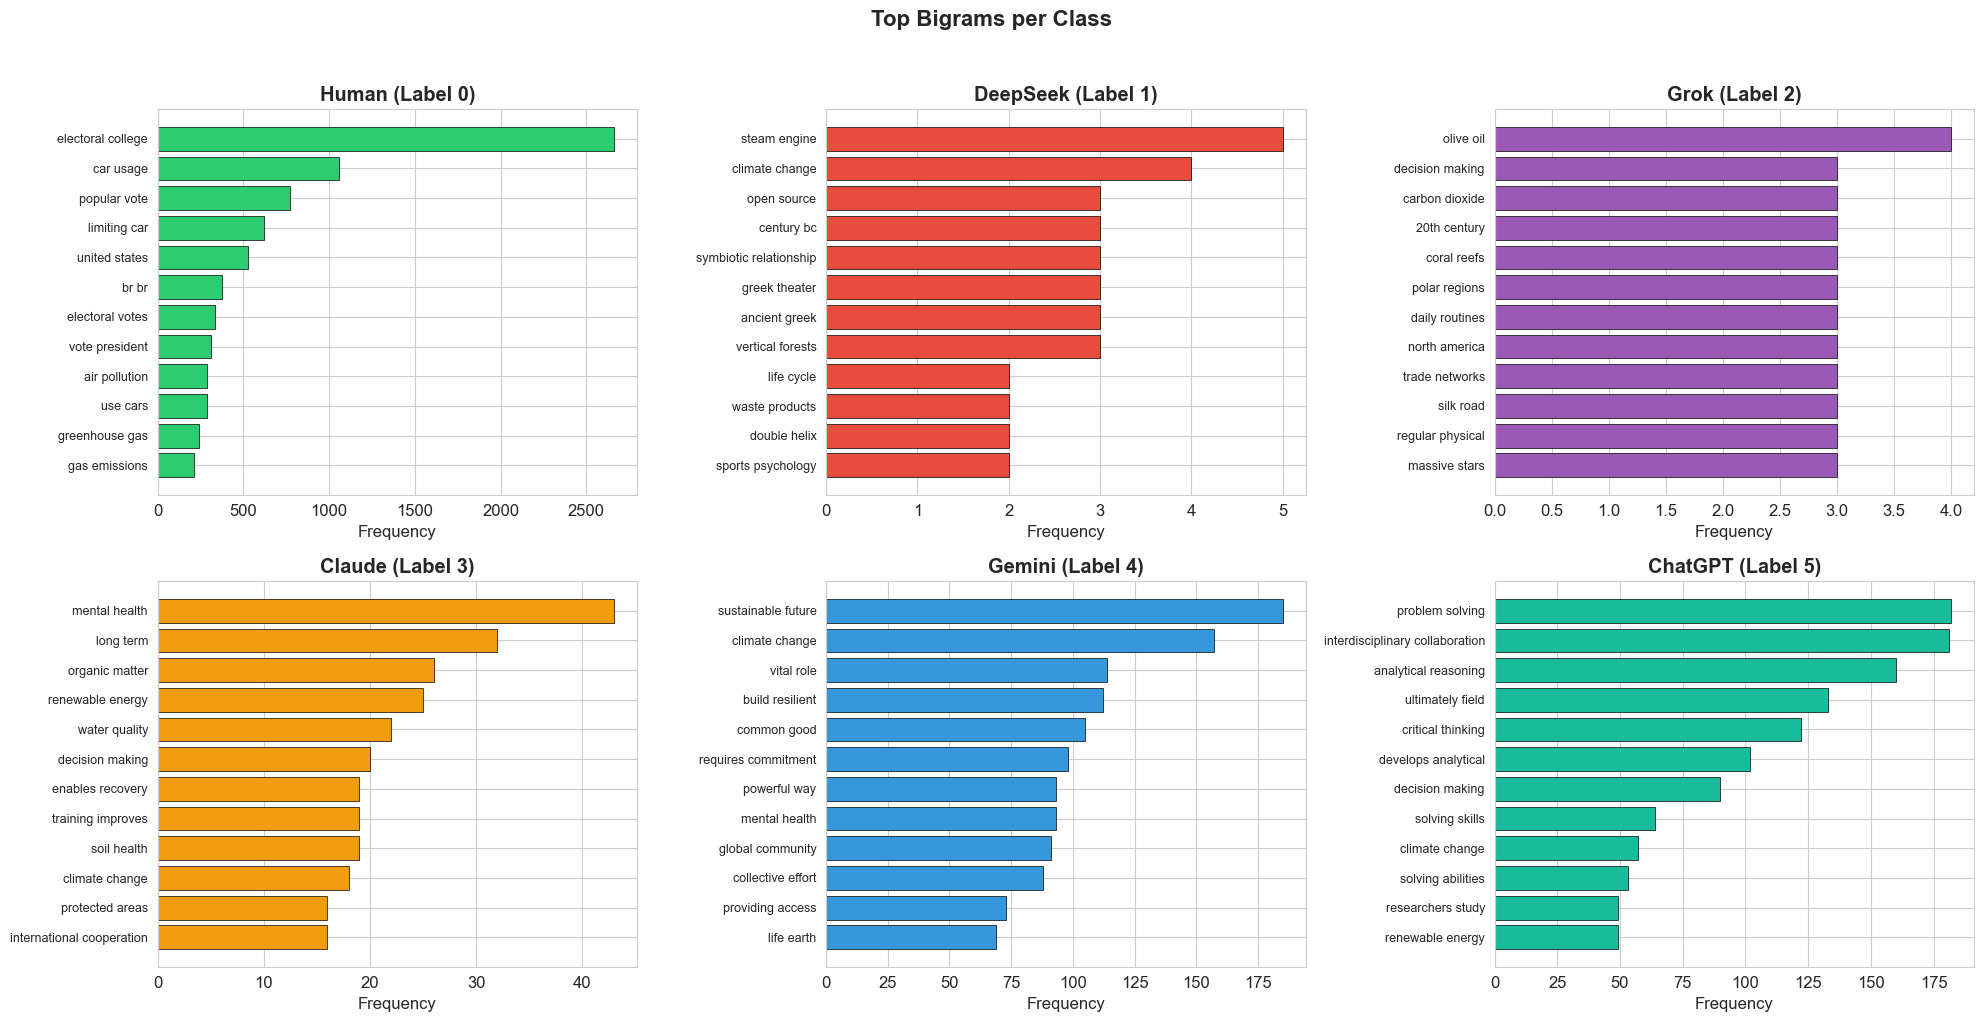

In [42]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=2, top_k=15):
    """Get top-k n-grams from a corpus."""
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=5000)
    bag = vec.fit_transform(corpus)
    sum_words = bag.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]
    return words_freq

fig, axes = plt.subplots(2, 3, figsize=(20, 10))

for idx, label in enumerate(sorted(train['LABEL'].unique())):
    ax = axes[idx // 3][idx % 3]
    name = LABEL_MAP[label]
    subset = train[train['LABEL'] == label]['TEXT']
    top_bigrams = get_top_ngrams(subset, n=2, top_k=12)
 
    words, counts = zip(*top_bigrams) if top_bigrams else ([], [])
    ax.barh(range(len(words)), counts, color=COLORS[name], edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f'{name} (Label {label})', fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Top Bigrams per Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/top_bigrams.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Save Baseline Models for Later Phases

Save the trained TF-IDF vectorizers and classifiers so they can be loaded in subsequent notebooks without retraining.


In [47]:
import joblib

os.makedirs('models', exist_ok=True)

# Save TF-IDF vectorizers (trained on full data)
joblib.dump(tfidf_word_full, 'models/baseline_tfidf_word.joblib')
joblib.dump(tfidf_char_full, 'models/baseline_tfidf_char.joblib')
print('Saved: baseline_tfidf_word.joblib, baseline_tfidf_char.joblib')

# Save classifiers
joblib.dump(final_model, 'models/baseline_svc.joblib')
joblib.dump(lr, 'models/baseline_lr.joblib')
print('Saved: baseline_svc.joblib, baseline_lr.joblib')

print('\nAll Phase 1 models saved to models/ for reuse in later phases.')


Saved: baseline_tfidf_word.joblib, baseline_tfidf_char.joblib
Saved: baseline_svc.joblib, baseline_lr.joblib

All Phase 1 models saved to models/ for reuse in later phases.


## 7. Key EDA Insights Summary

Run the cell below to print a summary of all our findings so far.

In [43]:
print('=' * 60)
print(' EDA INSIGHTS SUMMARY')
print('=' * 60)

print('\n1 CLASS IMBALANCE:')
print(f' Worst ratio: {class_counts.max()}:{class_counts.min()} (Human vs DeepSeek/Claude)')
print(f' → Must use class_weight="balanced" or similar strategies')

print('\n2 MISSPELLING SIGNAL:')
human_spell = train[train['LABEL']==0]['misspell_ratio'].mean()
ai_spell = train[train['LABEL']!=0]['misspell_ratio'].mean()
print(f' Human avg misspell ratio: {human_spell:.4f}')
print(f' AI avg misspell ratio: {ai_spell:.4f}')
print(f' → Misspelling ratio is a STRONG discriminator for Human vs AI')

print('\n3 TEXT LENGTH:')
for label in sorted(train['LABEL'].unique()):
    name = LABEL_MAP[label]
    avg_wc = train[train['LABEL']==label]['word_count'].mean()
    print(f' {name:>8s}: avg {avg_wc:.0f} words')

print('\n4 VOCABULARY RICHNESS (TTR):')
for label in sorted(train['LABEL'].unique()):
    name = LABEL_MAP[label]
    avg_ttr = train[train['LABEL']==label]['ttr'].mean()
    print(f' {name:>8s}: avg TTR = {avg_ttr:.4f}')

print('\n5 UPPERCASE USAGE:')
for label in sorted(train['LABEL'].unique()):
    name = LABEL_MAP[label]
    avg_upper = train[train['LABEL']==label]['upper_ratio'].mean()
    print(f' {name:>8s}: avg upper ratio = {avg_upper:.4f}')

print('\n' + '=' * 60)

 EDA INSIGHTS SUMMARY

1 CLASS IMBALANCE:
 Worst ratio: 1520:80 (Human vs DeepSeek/Claude)
 → Must use class_weight="balanced" or similar strategies

2 MISSPELLING SIGNAL:
 Human avg misspell ratio: 0.1415
 AI avg misspell ratio: 0.2122
 → Misspelling ratio is a STRONG discriminator for Human vs AI

3 TEXT LENGTH:
    Human: avg 451 words
 DeepSeek: avg 83 words
     Grok: avg 56 words
   Claude: avg 376 words
   Gemini: avg 420 words
  ChatGPT: avg 179 words

4 VOCABULARY RICHNESS (TTR):
    Human: avg TTR = 0.5294
 DeepSeek: avg TTR = 0.8630
     Grok: avg TTR = 0.9076
   Claude: avg TTR = 0.5991
   Gemini: avg TTR = 0.5954
  ChatGPT: avg TTR = 0.7204

5 UPPERCASE USAGE:
    Human: avg upper ratio = 0.0547
 DeepSeek: avg upper ratio = 0.0120
     Grok: avg upper ratio = 0.0135
   Claude: avg upper ratio = 0.0241
   Gemini: avg upper ratio = 0.0099
  ChatGPT: avg upper ratio = 0.0043



---
## 8. Baseline Model #1: TF-IDF + Logistic Regression

In [44]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

X = train['TEXT'].values
y = train['LABEL'].values

# Stratified train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
    )

print(f'Train size: {len(X_train)}, Val size: {len(X_val)}')
print(f'Train label dist: {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Val label dist: {dict(zip(*np.unique(y_val, return_counts=True)))}')

Train size: 1920, Val size: 480
Train label dist: {np.int64(0): np.int64(1216), np.int64(1): np.int64(64), np.int64(2): np.int64(128), np.int64(3): np.int64(64), np.int64(4): np.int64(192), np.int64(5): np.int64(256)}
Val label dist: {np.int64(0): np.int64(304), np.int64(1): np.int64(16), np.int64(2): np.int64(32), np.int64(3): np.int64(16), np.int64(4): np.int64(48), np.int64(5): np.int64(64)}


### TF-IDF Vectorization

Fit TF-IDF vectorizers on the combined corpus and transform both training and test data into sparse feature matrices.


In [45]:
# --- Model 1: TF-IDF (word) + Logistic Regression ---
print(' Training: TF-IDF (word) + Logistic Regression')
print('-' * 50)

tfidf_word = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    strip_accents='unicode',
    min_df=2
    )

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=1.0,
    random_state=42
    )

X_train_tfidf = tfidf_word.fit_transform(X_train)
X_val_tfidf = tfidf_word.transform(X_val)

lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_val_tfidf)

macro_f1_lr = f1_score(y_val, y_pred_lr, average='macro')
print(f'\n Macro F1 (Logistic Regression): {macro_f1_lr:.4f}')
print(f'\n{classification_report(y_val, y_pred_lr, target_names=[LABEL_MAP[i] for i in range(6)])}')

 Training: TF-IDF (word) + Logistic Regression
--------------------------------------------------

 Macro F1 (Logistic Regression): 0.9305

              precision    recall  f1-score   support

       Human       0.99      1.00      1.00       304
    DeepSeek       0.83      0.62      0.71        16
        Grok       0.84      0.97      0.90        32
      Claude       1.00      1.00      1.00        16
      Gemini       1.00      0.98      0.99        48
     ChatGPT       1.00      0.97      0.98        64

    accuracy                           0.98       480
   macro avg       0.94      0.92      0.93       480
weighted avg       0.98      0.98      0.98       480


 Macro F1 (Logistic Regression): 0.9305

              precision    recall  f1-score   support

       Human       0.99      1.00      1.00       304
    DeepSeek       0.83      0.62      0.71        16
        Grok       0.84      0.97      0.90        32
      Claude       1.00      1.00      1.00        16
    

## 9. Confusion Matrix -- Best Model

###  Training & Evaluation — Character N-gram Model

Train and evaluate a Logistic Regression model on character-level TF-IDF features.

=== Model Comparison ===
 TF-IDF(word) + LR              Macro F1 = 0.9305
 TF-IDF(word+char) + SVC        Macro F1 = 0.9207
 TF-IDF(char) + LR              Macro F1 = 0.9037

 Best model: TF-IDF(word) + LR (Macro F1 = 0.9305)


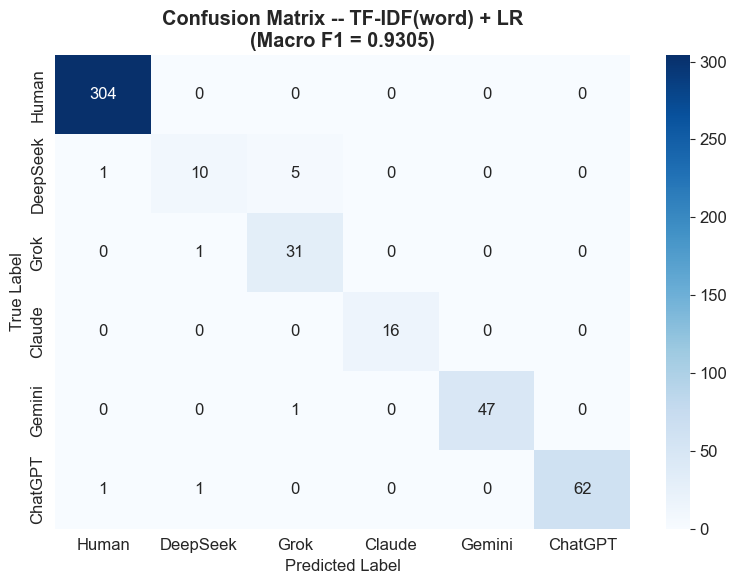

In [49]:
# Pick the best model so far
results = {
    'TF-IDF(word) + LR': (macro_f1_lr, y_pred_lr),
    'TF-IDF(char) + LR': (macro_f1_char, y_pred_char),
    'TF-IDF(word+char) + SVC': (macro_f1_svc, y_pred_svc),
    }

print('=== Model Comparison ===')
for name, (score, _) in sorted(results.items(), key=lambda x: x[1][0], reverse=True):
    print(f' {name:30s} Macro F1 = {score:.4f}')

best_name = max(results, key=lambda x: results[x][0])
best_f1, best_preds = results[best_name]
print(f'\n Best model: {best_name} (Macro F1 = {best_f1:.4f})')

# Confusion matrix
cm = confusion_matrix(y_val, best_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[LABEL_MAP[i] for i in range(6)],
    yticklabels=[LABEL_MAP[i] for i in range(6)],
    ax=ax)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title(f'Confusion Matrix -- {best_name}\n(Macro F1 = {best_f1:.4f})', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Cross-Validation (Best Model)

In [50]:
from sklearn.model_selection import StratifiedKFold

print(f'Running 5-fold Stratified CV for best approach...')
print('-' * 50)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_vl = X[train_idx], X[val_idx]
    y_tr, y_vl = y[train_idx], y[val_idx]
 
    # Word TF-IDF
    tfidf_w = TfidfVectorizer(max_features=30000, ngram_range=(1, 2),
        sublinear_tf=True, strip_accents='unicode', min_df=2)
    # Char TF-IDF
    tfidf_c = TfidfVectorizer(analyzer='char_wb', max_features=50000,
        ngram_range=(3, 5), sublinear_tf=True, min_df=2)
 
    X_tr_w = tfidf_w.fit_transform(X_tr)
    X_vl_w = tfidf_w.transform(X_vl)
    X_tr_c = tfidf_c.fit_transform(X_tr)
    X_vl_c = tfidf_c.transform(X_vl)
 
    X_tr_comb = hstack([X_tr_w, X_tr_c])
    X_vl_comb = hstack([X_vl_w, X_vl_c])
 
    model = LinearSVC(class_weight='balanced', C=1.0, max_iter=5000, random_state=42)
    model.fit(X_tr_comb, y_tr)
    y_pred = model.predict(X_vl_comb)
 
    fold_f1 = f1_score(y_vl, y_pred, average='macro')
    cv_scores.append(fold_f1)
    print(f' Fold {fold+1}: Macro F1 = {fold_f1:.4f}')

print(f'\n CV Mean Macro F1: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}')

Running 5-fold Stratified CV for best approach...
--------------------------------------------------
 Fold 1: Macro F1 = 0.9151
 Fold 1: Macro F1 = 0.9151
 Fold 2: Macro F1 = 0.8664
 Fold 2: Macro F1 = 0.8664
 Fold 3: Macro F1 = 0.8849
 Fold 3: Macro F1 = 0.8849
 Fold 4: Macro F1 = 0.9145
 Fold 4: Macro F1 = 0.9145
 Fold 5: Macro F1 = 0.8865

 CV Mean Macro F1: 0.8935 ± 0.0188
 Fold 5: Macro F1 = 0.8865

 CV Mean Macro F1: 0.8935 ± 0.0188


## 11. Generate Kaggle Submission

In [51]:
# Retrain on FULL training data and predict on test set
print('Retraining best model on full training data...')

# Fit TF-IDF on full train
tfidf_word_full = TfidfVectorizer(
    max_features=30000, ngram_range=(1, 2),
    sublinear_tf=True, strip_accents='unicode', min_df=2
    )
tfidf_char_full = TfidfVectorizer(
    analyzer='char_wb', max_features=50000,
    ngram_range=(3, 5), sublinear_tf=True, min_df=2
    )

X_full_word = tfidf_word_full.fit_transform(X)
X_full_char = tfidf_char_full.fit_transform(X)
X_full = hstack([X_full_word, X_full_char])

final_model = LinearSVC(class_weight='balanced', C=1.0, max_iter=5000, random_state=42)
final_model.fit(X_full, y)
print(' Model trained on full data')

# Transform test data
test_texts = test['TEXT'].values
X_test_word = tfidf_word_full.transform(test_texts)
X_test_char = tfidf_char_full.transform(test_texts)
X_test = hstack([X_test_word, X_test_char])

# Predict
test_preds = final_model.predict(X_test)

# Create submission file
os.makedirs('submissions', exist_ok=True)
submission_path = 'submissions/baseline_tfidf_svc.csv'
submission = pd.DataFrame({'ID': range(600), 'LABEL': test_preds})
submission.to_csv(submission_path, index=False)

print(f'Submission saved to: {submission_path}')
print(f'Shape: {submission.shape}')
print(f'\nPrediction distribution:')
for label in sorted(submission['LABEL'].unique()):
    count = (submission['LABEL'] == label).sum()
    print(f'  Label {label} ({LABEL_MAP[label]:>8s}): {count}')

print(f'\nFirst 10 rows:')
display(submission.head(10))

Retraining best model on full training data...
 Model trained on full data
 Model trained on full data
Submission saved to: submissions/baseline_tfidf_svc.csv
Shape: (600, 2)

Prediction distribution:
  Label 0 (   Human): 380
  Label 1 (DeepSeek): 9
  Label 2 (    Grok): 50
  Label 3 (  Claude): 20
  Label 4 (  Gemini): 60
  Label 5 ( ChatGPT): 81

First 10 rows:
Submission saved to: submissions/baseline_tfidf_svc.csv
Shape: (600, 2)

Prediction distribution:
  Label 0 (   Human): 380
  Label 1 (DeepSeek): 9
  Label 2 (    Grok): 50
  Label 3 (  Claude): 20
  Label 4 (  Gemini): 60
  Label 5 ( ChatGPT): 81

First 10 rows:


,ID,LABEL
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
5,5,5
6,6,0
7,7,0
8,8,5
9,9,3


### TF-IDF Vectorization — Full-Data Retrain & Submission

Retrain on the full training set (no validation split) and generate test predictions for submission.

In [52]:
# Also submit TF-IDF(word) + LR model (best single-split F1)
print('Training TF-IDF(word) + LR on full data...')

tfidf_word_full2 = TfidfVectorizer(
    max_features=30000, ngram_range=(1, 2),
    sublinear_tf=True, strip_accents='unicode', min_df=2
    )
lr_full = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, random_state=42)

X_full_word2 = tfidf_word_full2.fit_transform(X)
lr_full.fit(X_full_word2, y)

X_test_word2 = tfidf_word_full2.transform(test_texts)
test_preds_lr = lr_full.predict(X_test_word2)

lines_lr = ['ID,LABEL'] + [f'{i},{test_preds_lr[i]}' for i in range(600)]
submission_lr_path = 'submissions/baseline_tfidf_lr.csv'
with open(submission_lr_path, 'w') as f:
    f.write('\n'.join(lines_lr) + '\n')

print(f' Saved to {submission_lr_path}')
print(f'Prediction distribution:')
for label in sorted(np.unique(test_preds_lr)):
    count = (test_preds_lr == label).sum()
    print(f' Label {label} ({LABEL_MAP[label]:>8s}): {count}')

Training TF-IDF(word) + LR on full data...
 Saved to submissions/baseline_tfidf_lr.csv
Prediction distribution:
 Label 0 (   Human): 380
 Label 1 (DeepSeek): 11
 Label 2 (    Grok): 48
 Label 3 (  Claude): 20
 Label 4 (  Gemini): 61
 Label 5 ( ChatGPT): 80
 Saved to submissions/baseline_tfidf_lr.csv
Prediction distribution:
 Label 0 (   Human): 380
 Label 1 (DeepSeek): 11
 Label 2 (    Grok): 48
 Label 3 (  Claude): 20
 Label 4 (  Gemini): 61
 Label 5 ( ChatGPT): 80


## 12. Summary & Key Findings & Next Steps

### What we learned:
- **Class imbalance** is severe (19:1 ratio, Human vs DeepSeek/Claude)
- **Misspelling ratio** is likely the strongest single feature (Human >> AI)
- **Char n-grams** capture spelling patterns well
- **TF-IDF + LinearSVC** with balanced weights is a strong baseline

### Next Steps (Phase 2):
- Deeper feature engineering (stylometric + spelling features)
- XGBoost / LightGBM with handcrafted features
- Tune TF-IDF hyperparameters
- Try combining TF-IDF + handcrafted features

In [53]:
# Phase 1 smoke test: validate saved artifacts + submission format
import os
import pandas as pd
import joblib

os.chdir('/Users/aliivaezii/Documents/MALTO')

# Check submissions
for p in ['submissions/baseline_tfidf_svc.csv', 'submissions/baseline_tfidf_lr.csv']:
    df = pd.read_csv(p)
    assert list(df.columns) == ['ID', 'LABEL'], f'{p}: bad columns {df.columns.tolist()}'
    assert df.shape == (600, 2), f'{p}: bad shape {df.shape}'
    assert df['ID'].is_monotonic_increasing and df['ID'].min() == 0 and df['ID'].max() == 599, f'{p}: bad ID range'
    assert df['LABEL'].between(0, 5).all(), f'{p}: labels out of range'
print(' Submission CSVs look valid (600 rows, ID 0..599, labels 0..5).')

# Check models can be loaded
paths = [
    'models/baseline_tfidf_word.joblib',
    'models/baseline_tfidf_char.joblib',
    'models/baseline_svc.joblib',
    'models/baseline_lr.joblib',
]
for p in paths:
    obj = joblib.load(p)
    print(f' Loaded {p}: {type(obj)}')

print(' Phase 1 artifacts load successfully.')

 Submission CSVs look valid (600 rows, ID 0..599, labels 0..5).
 Loaded models/baseline_tfidf_word.joblib: <class 'sklearn.feature_extraction.text.TfidfVectorizer'>
 Loaded models/baseline_tfidf_char.joblib: <class 'sklearn.feature_extraction.text.TfidfVectorizer'>
 Loaded models/baseline_svc.joblib: <class 'sklearn.svm._classes.LinearSVC'>
 Loaded models/baseline_lr.joblib: <class 'sklearn.linear_model._logistic.LogisticRegression'>
 Phase 1 artifacts load successfully.
